In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [8]:
import pandas as pd

recall_df = pd.read_csv("recall.csv")
shapley_df = pd.read_csv("shapley.csv")
recall_df = recall_df[recall_df["algorithm"] == "EA"]
print("Recall Data:")
display(recall_df.head(10))

print("\nShapley Data:")
display(shapley_df.sort_values("shapley_recall", ascending=False).head(10))

Recall Data:


,algorithm,objectives,recall
2,EA,stft_kl_divergence,0.70
3,EA,stft_js_divergence,0.70
6,EA,stft_cosh,0.65
7,EA,iirt_cosh,0.63
8,EA,cqt_kl_divergence,0.60
9,EA,melspectrogram_cosh,0.59
10,EA,hybrid_cqt_cosh,0.58
11,EA,cqt_cosh,0.58
12,EA,stft_beta_divergence,0.58
13,EA,cqt_beta_divergence,0.56



Shapley Data:


,Unnamed: 0,shapley_acc,shapley_recall
93,iirt_kl_divergence,0.021602,0.028602
34,cqt_js_divergence,0.019511,0.028205
4,stft_js_divergence,0.025023,0.026985
3,stft_kl_divergence,0.030855,0.026971
35,cqt_manhattan,0.019793,0.024707
2,stft_cosh,0.025460,0.023829
84,hybrid_cqt_js_divergence,0.022311,0.022322
15,melspectrogram_manhattan,0.011294,0.022062
33,cqt_kl_divergence,0.019341,0.021512
92,iirt_cosh,0.019979,0.021357


In [3]:

len(recall_df)

100

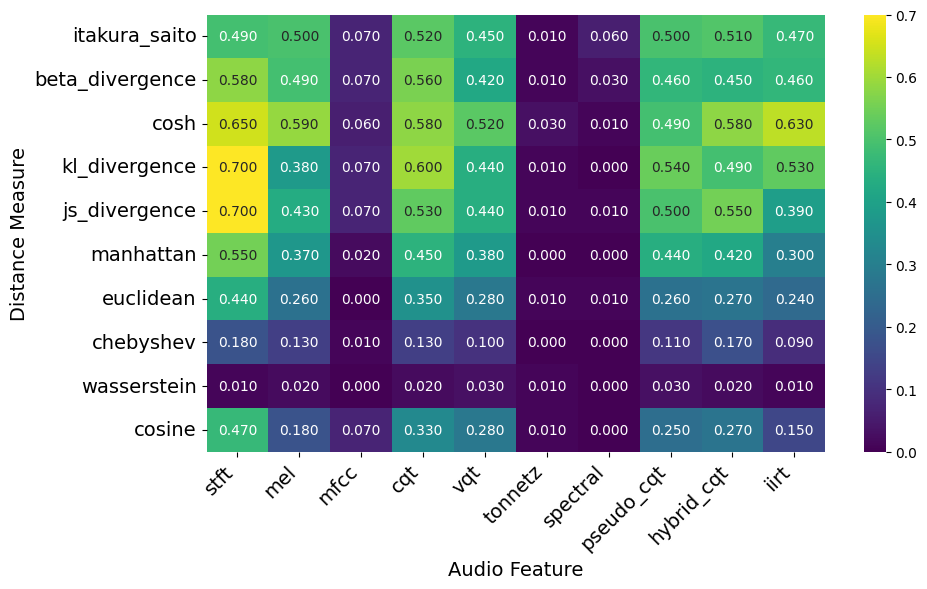

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

recall_df = pd.read_csv("recall.csv")

audio_features = [
    "stft", "melspectrogram", "mfcc", "cqt", "vqt",
    "tonnetz", "spectral", "pseudo_cqt", "hybrid_cqt", "iirt"
]

distance_measures = [
    "itakura_saito", "beta_divergence", "cosh", "kl_divergence",
    "js_divergence", "manhattan", "euclidean", "chebyshev",
    "wasserstein", "cosine"
]

def split_objective(obj):
    for dist in distance_measures:
        suffix = "_" + dist
        if obj.endswith(suffix):
            feature = obj[:-len(suffix)]
            if feature in audio_features:
                return feature, dist
    return None, None

recall_df[["audio_feature", "distance"]] = recall_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)

recall_df = recall_df.dropna(subset=["audio_feature", "distance"])

if recall_df["audio_feature"].isna().any():
    print("Warning: Some rows could not be parsed.")

# Pivot table
pivot = recall_df.pivot(
    index="distance",
    columns="audio_feature",
    values="recall"
)
pivot = pivot.reindex(index=distance_measures, columns=audio_features)
pivot = pivot.rename(columns={"melspectrogram": "mel"})

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    annot_kws={"size": 10}
)

plt.ylabel("Distance Measure", fontsize=14)
plt.xlabel("Audio Feature", fontsize=14)

plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()
outpath = os.path.join("experiments", "moea", "plots", "recall_heatmap.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

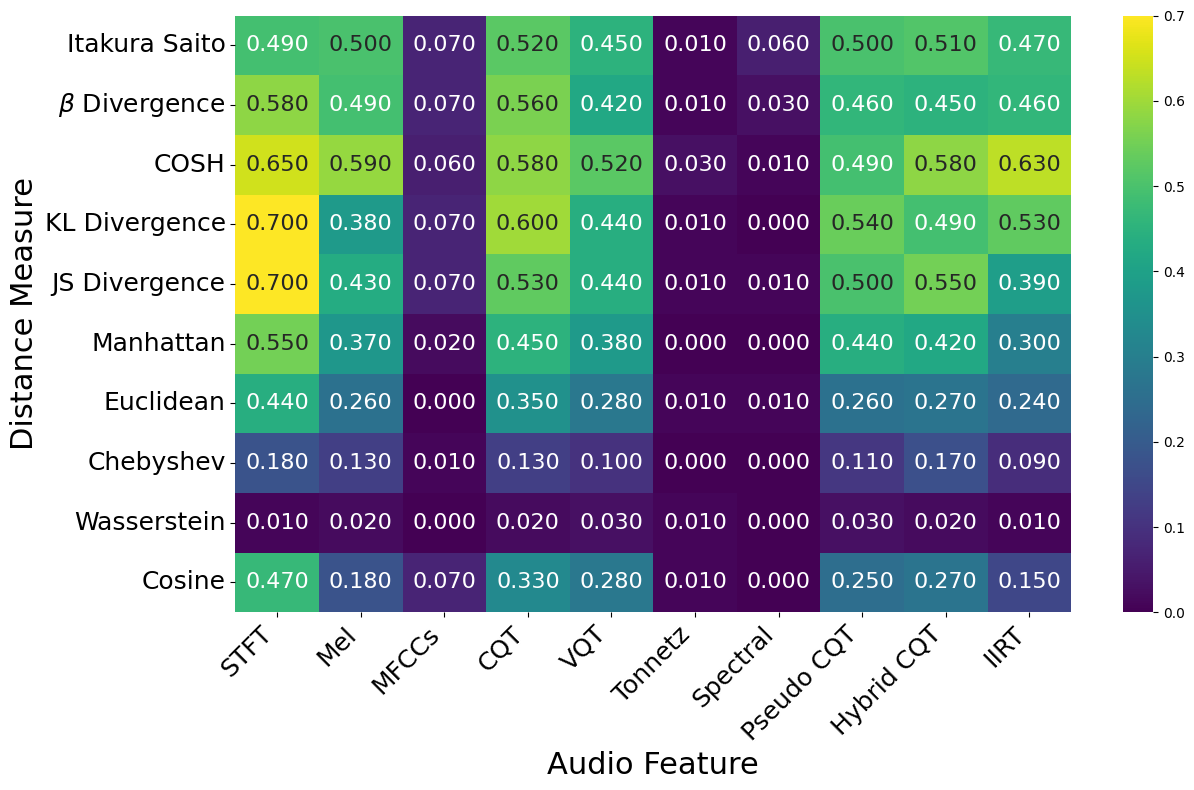

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

recall_df = pd.read_csv("recall.csv")

audio_features = [
    "stft", "melspectrogram", "mfcc", "cqt", "vqt",
    "tonnetz", "spectral", "pseudo_cqt", "hybrid_cqt", "iirt"
]

distance_measures = [
    "itakura_saito", "beta_divergence", "cosh", "kl_divergence",
    "js_divergence", "manhattan", "euclidean", "chebyshev",
    "wasserstein", "cosine"
]

ABBREVIATIONS = {
    "stft", "mfcc", "cqt", "vqt", "iirt",
    "kl", "js", "cosh"
}

def format_label(label):
    parts = label.split("_")
    formatted = []
    for p in parts:
        if p == "beta":
            formatted.append(r"$\beta$")
        elif p in ABBREVIATIONS:
            formatted.append(p.upper())
        else:
            formatted.append(p.capitalize())
    return " ".join(formatted)

def split_objective(obj):
    for dist in distance_measures:
        suffix = "_" + dist
        if obj.endswith(suffix):
            feature = obj[:-len(suffix)]
            if feature in audio_features:
                return feature, dist
    return None, None

recall_df[["audio_feature", "distance"]] = recall_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)

recall_df = recall_df.dropna(subset=["audio_feature", "distance"])

pivot = recall_df.pivot(
    index="distance",
    columns="audio_feature",
    values="recall"
)

pivot = pivot.reindex(index=distance_measures, columns=audio_features)

# ---- CLEAN LABELS ----
pivot.index = [format_label(i) for i in pivot.index]
pivot.columns = [format_label(c) for c in pivot.columns]
pivot = pivot.rename(columns={"Melspectrogram": "Mel"})
pivot = pivot.rename(columns={"MFCC": "MFCCs"})

# ---- PLOT ----
plt.figure(figsize=(13, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    annot_kws={"size": 16} 
)

plt.ylabel("Distance Measure", fontsize=22)
plt.xlabel("Audio Feature", fontsize=22)

plt.xticks(fontsize=18, rotation=45, ha="right")
plt.yticks(fontsize=18, rotation=0)

plt.tight_layout()

# ---- SAVE AS VECTOR PDF ----
outpath = os.path.join("experiments", "moea", "plots", "recall_heatmap.pdf")
plt.savefig(outpath, format="pdf", bbox_inches="tight")

plt.show()

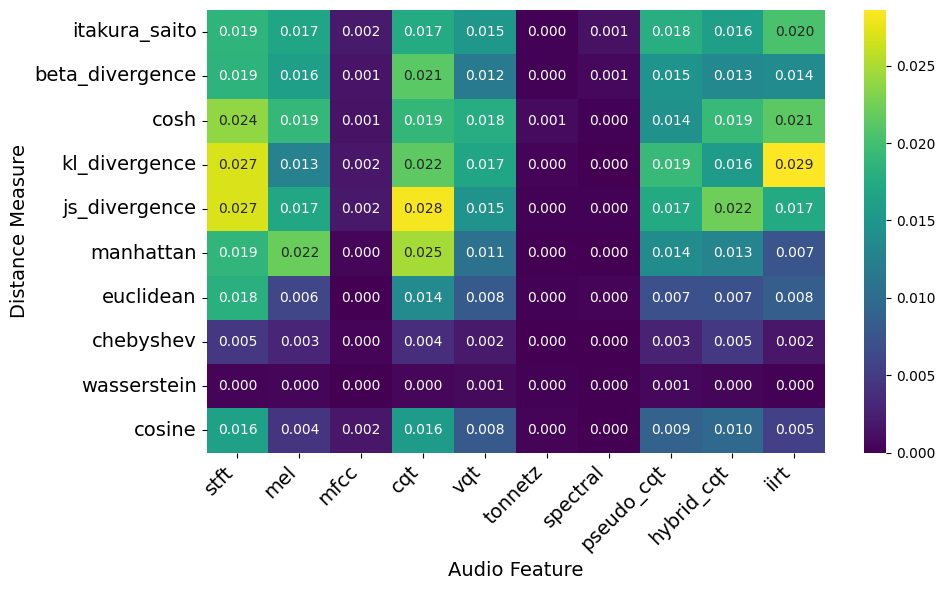

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

shapley_df = pd.read_csv("shapley.csv")
shapley_df = shapley_df.rename(columns={"Unnamed: 0": "objectives"})
shapley_df[["audio_feature", "distance"]] = shapley_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)


shapley_df = shapley_df.dropna(subset=["audio_feature", "distance"])
agg_df = shapley_df.groupby(
    ["audio_feature", "distance"], as_index=False
)["shapley_recall"].mean()

# Pivot
pivot = agg_df.pivot(
    index="distance",
    columns="audio_feature",
    values="shapley_recall"
)

pivot = pivot.reindex(index=distance_measures, columns=audio_features)
pivot = pivot.rename(columns={"melspectrogram": "mel"})
pivot = pivot.rename(columns={"MFCC": "MFCCs"})

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    annot_kws={"size": 10}
)

plt.ylabel("Distance Measure", fontsize=14)
plt.xlabel("Audio Feature", fontsize=14)

plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()
outpath = os.path.join("experiments", "moea", "plots", "shapley_heatmap.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()


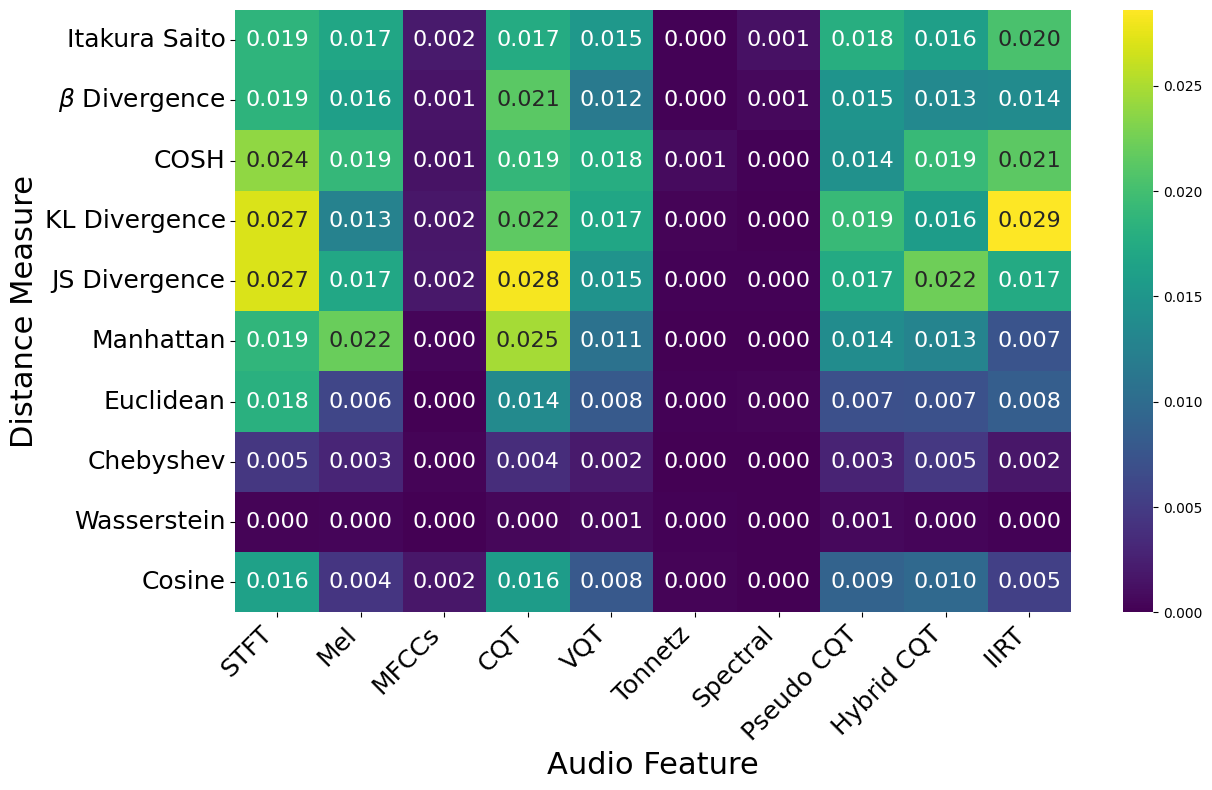

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

shapley_df = pd.read_csv("shapley.csv")
shapley_df = shapley_df.rename(columns={"Unnamed: 0": "objectives"})

ABBREVIATIONS = {
    "stft", "mfcc", "cqt", "vqt", "iirt",
    "kl", "js", "cosh"
}

def format_label(label):
    parts = label.split("_")
    formatted = []
    for p in parts:
        if p == "beta":
            formatted.append(r"$\beta$")
        elif p in ABBREVIATIONS:
            formatted.append(p.upper())
        else:
            formatted.append(p.capitalize())
    return " ".join(formatted)


shapley_df[["audio_feature", "distance"]] = shapley_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)

shapley_df = shapley_df.dropna(subset=["audio_feature", "distance"])
agg_df = shapley_df.groupby(
    ["audio_feature", "distance"], as_index=False
)["shapley_recall"].mean()

pivot = agg_df.pivot(
    index="distance",
    columns="audio_feature",
    values="shapley_recall"
)

pivot = pivot.reindex(index=distance_measures, columns=audio_features)

# ---- CLEAN LABELS ----
pivot.index = [format_label(i) for i in pivot.index]
pivot.columns = [format_label(c) for c in pivot.columns]

pivot = pivot.rename(columns={"Melspectrogram": "Mel"})
pivot = pivot.rename(columns={"MFCC": "MFCCs"})

# ---- PLOT ----
plt.figure(figsize=(13, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    annot_kws={"size": 16}
)

plt.ylabel("Distance Measure", fontsize=22)
plt.xlabel("Audio Feature", fontsize=22)

plt.xticks(fontsize=18, rotation=45, ha="right")
plt.yticks(fontsize=18, rotation=0)

plt.tight_layout()

# ---- SAVE AS VECTOR PDF ----
outpath = os.path.join("experiments", "moea", "plots", "shapley_heatmap.pdf")
plt.savefig(outpath, format="pdf", bbox_inches="tight")

plt.show()

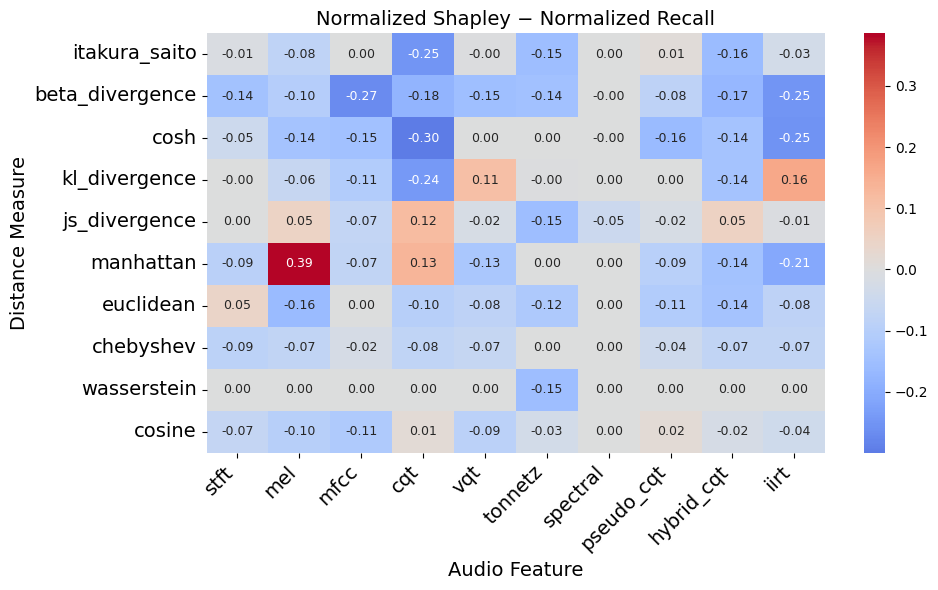

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LOAD DATA ----------
recall_df = pd.read_csv("recall.csv")
shapley_df = pd.read_csv("shapley.csv").rename(columns={"Unnamed: 0": "objectives"})

audio_features = [
    "stft", "melspectrogram", "mfcc", "cqt", "vqt",
    "tonnetz", "spectral", "pseudo_cqt", "hybrid_cqt", "iirt"
]

distance_measures = [
    "itakura_saito", "beta_divergence", "cosh", "kl_divergence",
    "js_divergence", "manhattan", "euclidean", "chebyshev",
    "wasserstein", "cosine"
]

# ---------- PARSING FUNCTION ----------
def split_objective(obj):
    for dist in distance_measures:
        suffix = "_" + dist
        if obj.endswith(suffix):
            feature = obj[:-len(suffix)]
            if feature in audio_features:
                return feature, dist
    return None, None

# Parse recall
recall_df[["audio_feature", "distance"]] = recall_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)
recall_df = recall_df.dropna(subset=["audio_feature", "distance"])

# Parse shapley
shapley_df[["audio_feature", "distance"]] = shapley_df["objectives"].apply(
    lambda x: pd.Series(split_objective(x))
)
shapley_df = shapley_df.dropna(subset=["audio_feature", "distance"])

# Aggregate (mean in case of duplicates)
recall_agg = recall_df.groupby(
    ["audio_feature", "distance"], as_index=False
)["recall"].mean()

shapley_agg = shapley_df.groupby(
    ["audio_feature", "distance"], as_index=False
)["shapley_recall"].mean()

# Pivot
recall_pivot = recall_agg.pivot(
    index="distance",
    columns="audio_feature",
    values="recall"
).reindex(index=distance_measures, columns=audio_features)

shapley_pivot = shapley_agg.pivot(
    index="distance",
    columns="audio_feature",
    values="shapley_recall"
).reindex(index=distance_measures, columns=audio_features)

# ---------- NORMALIZATION (per column) ----------
recall_norm = (recall_pivot - recall_pivot.min()) / (
    recall_pivot.max() - recall_pivot.min()
)

shapley_norm = (shapley_pivot - shapley_pivot.min()) / (
    shapley_pivot.max() - shapley_pivot.min()
)

# ---------- DIFFERENCE ----------
diff = shapley_norm - recall_norm
diff = diff.rename(columns={"melspectrogram": "mel"})

# ---------- PLOT ----------
plt.figure(figsize=(10, 6))
sns.heatmap(
    diff,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,        
    annot_kws={"size": 9}
)

plt.ylabel("Distance Measure", fontsize=14)
plt.xlabel("Audio Feature", fontsize=14)

plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14, rotation=0)

plt.title("Normalized Shapley − Normalized Recall", fontsize=14)

plt.tight_layout()
plt.show()
